In [24]:

from langchain_community.graphs import Neo4jGraph
from llama_index.llms.groq import Groq
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os

with open("groq_key.txt", 'r') as f:
    GROQ_API_KEY = f.readline().strip()

os.environ["GROQ_API_KEY"] = GROQ_API_KEY
os.environ["NEO4J_URI"] = "bolt://localhost:7687"
os.environ["NEO4J_USERNAME"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = "password"


##run:

# docker run \
#   --name neo4j \
#   -p 7474:7474 -p 7687:7687 \
#   -e NEO4J_AUTH=neo4j/password \
#   -e NEO4J_PLUGINS='["apoc"]' \
#   -e NEO4J_dbms_security_procedures_unrestricted=apoc.* \
#   -e NEO4J_dbms_security_procedures_allowlist=apoc.* \
#   neo4j

llm = Groq(temperature=0 ,model="moonshotai/kimi-k2-instruct-0905", api_key=GROQ_API_KEY)


In [25]:
from llama_index.core.llms import ChatMessage

messages = [ChatMessage(role="system", content = "You are an helpful assistant"),
            ChatMessage(role="user", content="What is Neo4j?")]

response = llm.chat(messages).message.content
print(response)

Neo4j is a high-performance, open-source **graph database** built from the ground-up to store and query **connected data**.  

Instead of tables (RDBMS) or collections of documents (MongoDB, etc.), Neo4j stores data as:

*   **Nodes** – the entities (analogous to rows or documents).  
*   **Relationships** – the typed, directed edges that connect any two nodes, always **first-class objects** with names, directions, and properties.  
*   **Properties** – key/value pairs attached to both nodes and relationships.  
*   **Labels** – used to group nodes (zero-to-many per node).  
*   **Relationship-types** – used to group relationships (one per relationship).

Because relationships are physical pointers in the storage layer, traversing them is **O(1)**—so joins and path queries stay fast even on graphs with billions of nodes.

**Main characteristics**

*   **Native graph storage and processing engine** (no hidden relational tables).  
*   **Declarative query language Cypher** – ASCII-art st

# Populate Neo4j db

In [62]:
#Add nodes
graph = Neo4jGraph(refresh_schema=True)

#Person
graph.query("CREATE (:Person {name:'Alice', profession:'Engineer', age:30})")
graph.query("CREATE (:Person {name:'Bob', profession: 'Doctor', age:'40'})")

#City
graph.query("CREATE (:City {name:'New York'})")

#Relationships
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name: 'Bob'}) CREATE (a)-[:FRIENDS_WITH]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:VISITED]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:WORKED_WITH]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:NEIGHBOR_OF]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:PARTNER_WITH]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:HAS_CHILD]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:CHILD_OF]->(b)")
graph.query("MATCH (a:Person {name:'Alice'}), (b:Person {name:'Bob'}) CREATE (a)-[:MARRIED_TO]->(b)")

# City contains Person
graph.query("MATCH (a:Person {name:'Alice'}), (c:City {name:'New York'}) CREATE (c)-[:CONTAINS]->(a)")


[]

In [2]:
graph = Neo4jGraph(refresh_schema=True)


C:\Users\Utente\AppData\Local\Temp\ipykernel_158960\916117425.py:1: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(refresh_schema=True)


In [3]:
graph.get_schema

'Node properties:\nPerson {age: INTEGER, profession: STRING, name: STRING}\nCity {name: STRING}\nCompany {name: STRING}\nPlace {name: STRING}\nProject {name: STRING}\nEvent {name: STRING}\nProfession {name: STRING}\nInstitute {name: STRING}\nRelationship properties:\n\nThe relationships:\n(:Person)-[:FRIENDS_WITH]->(:Person)\n(:Person)-[:VISITED]->(:Person)\n(:Person)-[:WORKED_WITH]->(:Person)\n(:Person)-[:NEIGHBOR_OF]->(:Person)\n(:Person)-[:PARTNER_WITH]->(:Person)\n(:Person)-[:HAS_CHILD]->(:Person)\n(:Person)-[:CHILD_OF]->(:Person)\n(:Person)-[:MARRIED_TO]->(:Person)\n(:Person)-[:LIVES_IN]->(:Place)\n(:Person)-[:LIVES_IN_CITY]->(:City)\n(:Person)-[:HAS_PROFESSION]->(:Profession)\n(:Person)-[:WORKS_AT]->(:Company)\n(:Person)-[:ATTENDS]->(:Event)\n(:Person)-[:COLLABORATES_ON]->(:Project)\n(:Person)-[:HOSTS]->(:Event)\n(:Person)-[:PARENT_OF]->(:Person)\n(:Person)-[:LEADS]->(:Institute)\n(:Person)-[:OWNS]->(:Place)\n(:Person)-[:LOCATED_IN]->(:Place)\n(:Person)-[:PRESENTS_AT]->(:Event)\n

# Create Knowledge Graph 

**TWO METHODS**:
1) CUSTOM
2) LANGCHAIN GRAPH TRANSFORMERS 

### CUSTOM METHOD

In [66]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser


prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content="""
    You are a helpful assistant in creates knowledge graphs by Generating Cypher Queries.\n

    Task:
     *  Identify Entities, Relationships and Property Keys from Context.\n
     *  Generate Cypher Query to Create Knowledge Graph from the Entities Relationships and Property Keys discovered.\n
     *  Extract ALL Entities and RelationShips as Possible.\n
     *  Always extract a person Profession as an Entity.\n
     *  Be creative.
     *  Understand hidden relationships from the network.
     Note: Read the Context twice and carefully before generating Cypher Query.\n
     Note: Do not return anything other than the Cypher Query.\n
     Note: Do not include any explanations or apologies in your responses.\n


     Note: Do not hallucinate.\n

     Entities include Person, Place, Product, WorkPlaces, Companies , City, Country, Animals, Tags like peoples Profession and more \n

     Few Shot Prompts:
      Example Context:

       Mary was born in 1995. She is Friends with Jane and John. Jane is 2 years older than Mary.
       Mary has a dog named Max,and is 3 years old. She is also married to John.Mary is from USA and a Software Engineer.

      Answer:
        MERGE (Mary:Person {name: "Mary", birth_year: 1995})
        MERGE (Jane:Person {name: "Jane", age:1993})
        MERGE (John:Person {name: "John"})
        MERGE (Mary)-[:FRIENDS_WITH]->(Jane)
        MERGE (Mary)-[:FRIENDS_WITH]->(John)
        MERGE (Jane)-[:FRIENDS_WITH]->(Mary)
        MERGE (John)-[:FRIENDS_WITH]->(Mary)
        MERGE (Mary)-[:HAS_DOG]->(Max:Dog {name: "Max", age: 3})
        MERGE (Mary)-[:MARRIED_TO]->(John)
        MERGE (Mary)-[:HAS_PROFESSION]->(SoftwareEngineer:Profession {name: "Software Engineer"})
        MERGE (Mary)-[:FROM]->(USA:Country {name: "USA"})


    """),
    ("human", "Context:{text}"),
])



In [67]:
with open("story.txt", "r") as f:
    content = f.read()

print(content)

### The Enchanted Network of NexCity

---

In the heart of the bustling metropolis of **NexCity**, where skyscrapers kissed the clouds and neon lights painted the night, lived Emma Thompson. Her apartment was a marvel of modern design, perched high above the city streets, a shimmering beacon of her success as a software developer. Little did she know, her life was about to become a thrilling tapestry of connections, adventures, and surprises.

#### **Chapter 1: The Birthday Bash**

One sunny Saturday, Emma received an invitation from her childhood friend, Alex Martin. Alex, now a thriving entrepreneur, lived in a charming suburban house with his partner, Jessica, and their two playful children, Lily and Max. The occasion? Maxâ€™s fifth birthday party, and it promised to be a grand affair.

Emma arrived at Alex's home to find the backyard transformed into a carnival. Colorful balloons floated in the breeze, and laughter echoed as children darted around a bouncy castle. Emma marveled at 

In [68]:
lang_msgs = prompt.format_messages(text=content)

groq_msgs = []
for m in lang_msgs:
    if isinstance(m, SystemMessage):
        role = "system"
    elif isinstance(m, HumanMessage):
        role = "user"
    elif isinstance(m, AIMessage):
        role = "assistant"
    else:
        role = getattr(m, "role", "user")
    groq_msgs.append(ChatMessage(role=role, content=m.content))


In [69]:
response = llm.chat(groq_msgs)
print(response.message.content)

```cypher
MERGE (Emma:Person {name: "Emma Thompson", profession: "Software Developer"})
MERGE (NexCity:City {name: "NexCity"})

MERGE (Alex:Person {name: "Alex Martin", profession: "Entrepreneur"})
MERGE (Jessica:Person {name: "Jessica"})
MERGE (Lily:Person {name: "Lily"})
MERGE (Max:Person {name: "Max", age: 5})
MERGE (Tom:Person {name: "Tom Wilson", profession: "Senior Developer"})
MERGE (Sarah:Person {name: "Sarah", profession: "Artist"})
MERGE (Maria:Person {name: "Maria Lopez", profession: "Environmental Research Institute Leader"})
MERGE (Jake:Person {name: "Jake Anderson", profession: "Chef"})
MERGE (Raj:Person {name: "Raj Patel", profession: "Data Scientist"})
MERGE (Nina:Person {name: "Nina", profession: "Community Organizer"})
MERGE (Leo:Person {name: "Leo Martinez", profession: "Financial Analyst"})
MERGE (Maya:Person {name: "Maya Chen", profession: "Startup Founder"})
MERGE (Helen:Person {name: "Helen Carter", profession: "Retired Teacher"})
MERGE (Chloe:Person {name: "Chlo

In [82]:
db_query = response.message.content.split('cypher')[1].strip("```").strip()
print(db_query)

MERGE (Emma:Person {name: "Emma Thompson", profession: "Software Developer"})
MERGE (NexCity:City {name: "NexCity"})

MERGE (Alex:Person {name: "Alex Martin", profession: "Entrepreneur"})
MERGE (Jessica:Person {name: "Jessica"})
MERGE (Lily:Person {name: "Lily"})
MERGE (Max:Person {name: "Max", age: 5})
MERGE (Tom:Person {name: "Tom Wilson", profession: "Senior Developer"})
MERGE (Sarah:Person {name: "Sarah", profession: "Artist"})
MERGE (Maria:Person {name: "Maria Lopez", profession: "Environmental Research Institute Leader"})
MERGE (Jake:Person {name: "Jake Anderson", profession: "Chef"})
MERGE (Raj:Person {name: "Raj Patel", profession: "Data Scientist"})
MERGE (Nina:Person {name: "Nina", profession: "Community Organizer"})
MERGE (Leo:Person {name: "Leo Martinez", profession: "Financial Analyst"})
MERGE (Maya:Person {name: "Maya Chen", profession: "Startup Founder"})
MERGE (Helen:Person {name: "Helen Carter", profession: "Retired Teacher"})
MERGE (Chloe:Person {name: "Chloe Edwards"

In [79]:
def create_knowledge_query(query:str):
    graph.query(query)

In [83]:
create_knowledge_query(f"""{db_query}""")

### LANGCHAIN GRAPH TRANSFORMER METHOD

In [4]:
from langchain_core.documents import Document
from langchain_experimental.graph_transformers import LLMGraphTransformer

llm_transformer = LLMGraphTransformer(llm=llm)
documents = [Document(page_content=content)]
graph_documents = llm_transformer.convert_to_graph_documents(documents)
print(f"Nodes:{graph_documents[0].nodes}")
print(f"Relationships:{graph_documents[0].relationships}")

AttributeError: 'Groq' object has no attribute 'with_structured_output'

In [ ]:
graph.add_graph_documents(graph_documents)

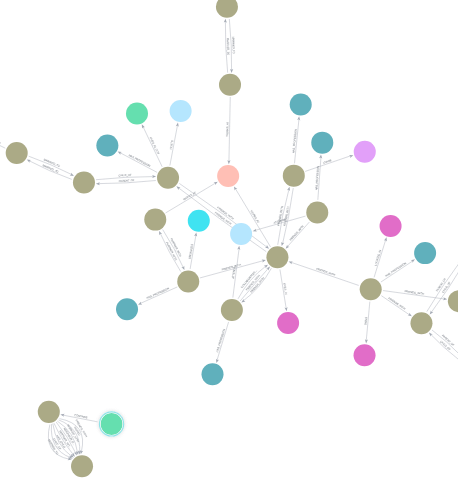

In [87]:
from IPython.display import Image, display

display(Image(filename="data/visualisation.png"))

Query the db with langchain

In [ ]:
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

graphchain = GraphCypherQAChain.from_llm(
    llm, graph=graph, verbose=True, return_intermediate_steps=True)


results = graphchain.invoke({"query":"People who have kids"})
print(results["result"])
     

AttributeError: 'GroqChain' object has no attribute 'get'

Or we can do manually

In [ ]:
nodes = graph.query("""
MATCH (n)
RETURN n.name AS name, labels(n) AS labels, properties(n) AS props
""")

for node in nodes:
    print(node)

{'name': 'Alice', 'labels': ['Person'], 'props': {'profession': 'Engineer', 'name': 'Alice', 'age': 30}}
{'name': 'Bob', 'labels': ['Person'], 'props': {'profession': 'Doctor', 'name': 'Bob', 'age': '40'}}
{'name': 'New York', 'labels': ['City'], 'props': {'name': 'New York'}}
{'name': 'Emma Thompson', 'labels': ['Person'], 'props': {'profession': 'Software Developer', 'name': 'Emma Thompson'}}
{'name': 'NexCity', 'labels': ['City'], 'props': {'name': 'NexCity'}}
{'name': 'Alex Martin', 'labels': ['Person'], 'props': {'profession': 'Entrepreneur', 'name': 'Alex Martin'}}
{'name': 'Jessica', 'labels': ['Person'], 'props': {'name': 'Jessica'}}
{'name': 'Lily', 'labels': ['Person'], 'props': {'name': 'Lily'}}
{'name': 'Max', 'labels': ['Person'], 'props': {'name': 'Max', 'age': 5}}
{'name': 'Tom Wilson', 'labels': ['Person'], 'props': {'profession': 'Senior Developer', 'name': 'Tom Wilson'}}
{'name': 'Sarah', 'labels': ['Person'], 'props': {'profession': 'Artist', 'name': 'Sarah'}}
{'name

In [14]:
rels = graph.query("""
MATCH (a)-[r]->(b)
RETURN a.name AS from, type(r) AS rel_type, b.name AS to
""")

for rel in rels:
    print(rel)

{'from': 'Alice', 'rel_type': 'FRIENDS_WITH', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'VISITED', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'WORKED_WITH', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'NEIGHBOR_OF', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'PARTNER_WITH', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'HAS_CHILD', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'CHILD_OF', 'to': 'Bob'}
{'from': 'Alice', 'rel_type': 'MARRIED_TO', 'to': 'Bob'}
{'from': 'New York', 'rel_type': 'CONTAINS', 'to': 'Alice'}
{'from': 'Emma Thompson', 'rel_type': 'LIVES_IN', 'to': "Emma's Apartment"}
{'from': 'Emma Thompson', 'rel_type': 'LIVES_IN_CITY', 'to': 'NexCity'}
{'from': 'Emma Thompson', 'rel_type': 'HAS_PROFESSION', 'to': 'Software Developer'}
{'from': 'Emma Thompson', 'rel_type': 'WORKS_AT', 'to': 'Innovatech'}
{'from': 'Emma Thompson', 'rel_type': 'FRIENDS_WITH', 'to': 'Alex Martin'}
{'from': 'Emma Thompson', 'rel_type': 'FRIENDS_WITH', 'to': 'Tom Wilson'}
{'from': 'Emma Thompson', 'rel_ty

In [15]:
db_context = "Nodes:\n"
for node in nodes:
    db_context += f"- {node['labels'][0]}: {node['name']}, properties: {node['props']}\n"

db_context += "\nRelationships:\n"
for rel in rels:
    db_context += f"- ({rel['from']}) -[:{rel['rel_type']}]-> ({rel['to']})\n"

print(db_context)

Nodes:
- Person: Alice, properties: {'profession': 'Engineer', 'name': 'Alice', 'age': 30}
- Person: Bob, properties: {'profession': 'Doctor', 'name': 'Bob', 'age': '40'}
- City: New York, properties: {'name': 'New York'}
- Person: Emma Thompson, properties: {'profession': 'Software Developer', 'name': 'Emma Thompson'}
- City: NexCity, properties: {'name': 'NexCity'}
- Person: Alex Martin, properties: {'profession': 'Entrepreneur', 'name': 'Alex Martin'}
- Person: Jessica, properties: {'name': 'Jessica'}
- Person: Lily, properties: {'name': 'Lily'}
- Person: Max, properties: {'name': 'Max', 'age': 5}
- Person: Tom Wilson, properties: {'profession': 'Senior Developer', 'name': 'Tom Wilson'}
- Person: Sarah, properties: {'profession': 'Artist', 'name': 'Sarah'}
- Person: Maria Lopez, properties: {'profession': 'Environmental Research Institute Leader', 'name': 'Maria Lopez'}
- Person: Jake Anderson, properties: {'profession': 'Chef', 'name': 'Jake Anderson'}
- Person: Raj Patel, properti

In [20]:
system_prompt = f"""
You are a Cypher query generator for a Neo4j database. 

Database structure:
{db_context}


Instructions:

1. Always generate **valid Cypher queries** that can run on Neo4j.
2. Do **not include any explanations** — output **only the Cypher query**.
3. Use **proper Cypher syntax**, including labels, relationships, and properties.
4. Only use information implied by the user query. Do not make assumptions about data that is not mentioned.
5. If the query is ambiguous, choose the most typical interpretation.
6. Always use `RETURN` to specify the output fields. Avoid using `LIMIT` unless explicitly asked.
7. Ensure the query is **safe** and will not perform destructive operations (no `DELETE` or `SET` unless explicitly instructed).
8. Keep queries concise, using best practices for readability.

Example:

- User input: "Find all movies directed by Christopher Nolan."
- Output: `MATCH (m:Movie)-[:DIRECTED_BY]->(d:Director {{name: 'Christopher Nolan'}}) RETURN m`

- User input: "List actors who played in Top Gun."
- Output: `MATCH (a:Actor)-[:ACTED_IN]->(m:Movie {{title: 'Top Gun'}}) RETURN a`

Now, translate the following user query into a Cypher query:

"""

In [27]:
def get_db_query(query):
    messages = [ChatMessage(role="system", content = system_prompt),
            ChatMessage(role="user", content=query)]

    response = llm.chat(messages).message.content

    return response

In [28]:
nlp_query = "People who have kids"
db_query = get_db_query(nlp_query)
db_query

'MATCH (p:Person)-[:HAS_CHILD|PARENT_OF]->(:Person) RETURN DISTINCT p'

In [29]:
def run_query(nlp_query):
    db_query = get_db_query(nlp_query)
    print(f"db query\n: {db_query}")

    result = graph.query(db_query)
    print(f"RESULT\n: {result}")

    return result

In [30]:
result = run_query(nlp_query)

db query
: MATCH (p:Person)-[:PARENT_OF]->(child) RETURN DISTINCT p
RESULT
: [{'p': {'profession': 'Entrepreneur', 'name': 'Alex Martin'}}, {'p': {'name': 'Jessica'}}, {'p': {'profession': 'Retired Teacher', 'name': 'Helen Carter'}}]
